# 01 — Exploring TLE Data & Orbital Propagation

This notebook covers the foundation of the satellite collision prediction system:

1. What TLE data is and where to get it
2. Parsing TLEs and propagating orbits with `sgp4`
3. Converting orbital positions to latitude/longitude
4. Plotting ground tracks
5. Computing distances between satellites
6. A basic close approach (conjunction) detector

Everything here will eventually become a proper service in the pipeline.

In [1]:
# Install dependencies if needed
!pip install sgp4 requests pandas numpy matplotlib

In [2]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from sgp4.api import Satrec, jday

print('All imports successful.')

All imports successful.


---
## 1. What is TLE Data?

A **Two-Line Element set (TLE)** is a standardized format for describing a satellite's orbit at a specific moment in time (the *epoch*). It looks like this:

```
ISS (ZARYA)
1 25544U 98067A   24001.00000000  .00000000  00000-0  00000-0 0  9999
2 25544  51.6400 000.0000 0001001 000.0000 000.0000 15.50000000000000
```

Key fields in **Line 1**:
- `25544` — NORAD catalog number (unique ID for every tracked object)
- `98067A` — International designator (launch year + sequence)
- `24001.00` — Epoch (day 1 of 2024)

Key fields in **Line 2**:
- `51.6400` — Inclination (degrees) — angle of orbit relative to equator
- `0001001` — Eccentricity — how elliptical the orbit is
- `15.5000` — Mean motion (revolutions per day) — how fast it orbits

The **SGP4** algorithm takes these numbers and computes where the satellite is at any future time.

---
## 2. Downloading TLE Data from Celestrak

In [74]:
# Hardcoded fallback TLE data (used if Celestrak is unreachable)
SAMPLE_TLES = [
    (
        'ISS (ZARYA)',
        '1 25544U 98067A   24083.54791435  .00018454  00000+0  33038-3 0  9993',
        '2 25544  51.6416 120.8756 0002651 352.5200 113.7897 15.50036278446053'
    ),
    (
        'CSS (TIANHE)',
        '1 48274U 21035A   24083.54037662  .00022451  00000+0  25480-3 0  9994',
        '2 48274  41.4695 124.4421 0005844 339.6846  20.3951 15.61719547161351'
    ),
]

def fetch_tle_data(url):
    """Fetch TLE data from Celestrak. Returns list of (name, line1, line2) tuples."""
    headers = {'User-Agent': 'satellite-collision-project/1.0'}
    response = requests.get(url, timeout=30, headers=headers)
    response.raise_for_status()
    lines = [l.strip() for l in response.text.strip().splitlines() if l.strip()]
    satellites = []
    for i in range(0, len(lines) - 2, 3):
        name, line1, line2 = lines[i], lines[i+1], lines[i+2]
        if line1.startswith('1') and line2.startswith('2'):
            satellites.append((name, line1, line2))
    return satellites

# Correct Celestrak GP data endpoints (updated from deprecated SOCRATES path)
ACTIVE_URL   = 'https://celestrak.org/NORAD/elements/gp.php?GROUP=active&FORMAT=tle'
STATIONS_URL = 'https://celestrak.org/NORAD/elements/gp.php?GROUP=stations&FORMAT=tle'
DEBRIS_URL   = 'https://celestrak.org/NORAD/elements/gp.php?GROUP=cosmos-2251-debris&FORMAT=tle'

print('Fetching space station TLEs...')
try:
    stations = fetch_tle_data(STATIONS_URL)
    print(f'Fetched {len(stations)} objects from Celestrak.')
except Exception as e:
    print(f'Celestrak unavailable ({e}) — using hardcoded sample TLEs.')
    stations = SAMPLE_TLES

print(f'\nFirst entry:')
print(f'  Name:  {stations[0][0]}')
print(f'  Line1: {stations[0][1]}')
print(f'  Line2: {stations[0][2]}')


Fetching space station TLEs...
Fetched 31 objects from Celestrak.

First entry:
  Name:  ISS (ZARYA)
  Line1: 1 25544U 98067A   26084.45430866  .00012951  00000+0  24673-3 0  9998
  Line2: 2 25544  51.6344 354.4276 0006214 231.1671 128.8763 15.48531543558776


In [75]:
print('Fetching active satellite TLEs (this may take a moment)...')
try:
    active_sats = fetch_tle_data(ACTIVE_URL)
    print(f'Fetched {len(active_sats)} active satellites from Celestrak.')
except Exception as e:
    print(f'Celestrak unavailable ({e}) — using sample TLEs as fallback.')
    active_sats = SAMPLE_TLES


Fetching active satellite TLEs (this may take a moment)...
Fetched 14874 active satellites from Celestrak.


---
## 3. Propagating a Single Orbit with SGP4

SGP4 gives us a satellite's position as **(x, y, z)** in km in the **ECI frame**
(Earth-Centered Inertial — origin is Earth's center, axes point toward fixed stars).

In [79]:
def build_satrec(name, line1, line2):
    return name, Satrec.twoline2rv(line1, line2)

def propagate(satrec, dt):
    """Compute ECI position (km) at a given datetime. Returns np.array or None."""
    jd, fr = jday(dt.year, dt.month, dt.day,
                  dt.hour, dt.minute, dt.second + dt.microsecond / 1e6)
    err, pos, vel = satrec.sgp4(jd, fr)
    return np.array(pos) if err == 0 else None

# Find the ISS
iss_entry = next((s for s in stations if 'ISS' in s[0].upper()), stations[0])
iss_name, iss_sat = build_satrec(*iss_entry)

now = datetime.utcnow()
pos = propagate(iss_sat, now)

print(f'Satellite : {iss_name}')
print(f'Time (UTC): {now.strftime("%Y-%m-%d %H:%M:%S")}')
print(f'Position  : x={pos[0]:.1f} km, y={pos[1]:.1f} km, z={pos[2]:.1f} km')
print(f'Distance from Earth center: {np.linalg.norm(pos):.1f} km')
print(f'Altitude (approx): {np.linalg.norm(pos) - 6371:.1f} km')

Satellite : ISS (ZARYA)
Time (UTC): 2026-03-26 01:21:50
Position  : x=-2940.6 km, y=4093.2 km, z=4557.5 km
Distance from Earth center: 6795.0 km
Altitude (approx): 424.0 km


/tmp/ipykernel_59375/3207010857.py:15: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  now = datetime.utcnow()


---
## 4. Converting ECI to Latitude & Longitude

ECI coordinates are great for distance math, but to plot on a map we need lat/lon.

In [77]:
def eci_to_latlon(pos, dt):
    """Convert ECI (x,y,z) to (latitude, longitude) in degrees."""
    x, y, z = pos
    jd, fr = jday(dt.year, dt.month, dt.day, dt.hour, dt.minute, dt.second)
    t = (jd + fr - 2451545.0) / 36525.0
    gmst = (280.46061837 + 360.98564736629 * (jd + fr - 2451545.0)
            + 0.000387933 * t**2 - t**3 / 38710000.0) % 360
    gmst_rad = np.radians(gmst)

    lon = np.degrees(np.arctan2(y, x) - gmst_rad) % 360
    if lon > 180:
        lon -= 360
    lat = np.degrees(np.arctan2(z, np.sqrt(x**2 + y**2)))
    return lat, lon

lat, lon = eci_to_latlon(pos, now)
print(f'{iss_name} is currently over:')
print(f'  Latitude : {lat:.2f} deg')
print(f'  Longitude: {lon:.2f} deg')

ISS (ZARYA) is currently over:
  Latitude : 50.65 deg
  Longitude: -134.85 deg


---
## 5. Plotting a Ground Track

A **ground track** is the path traced on Earth's surface directly below the satellite.

In [63]:
!pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 2.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 445.0/445.0 kB 3.3 MB/s eta 0:00:0000:0100:01


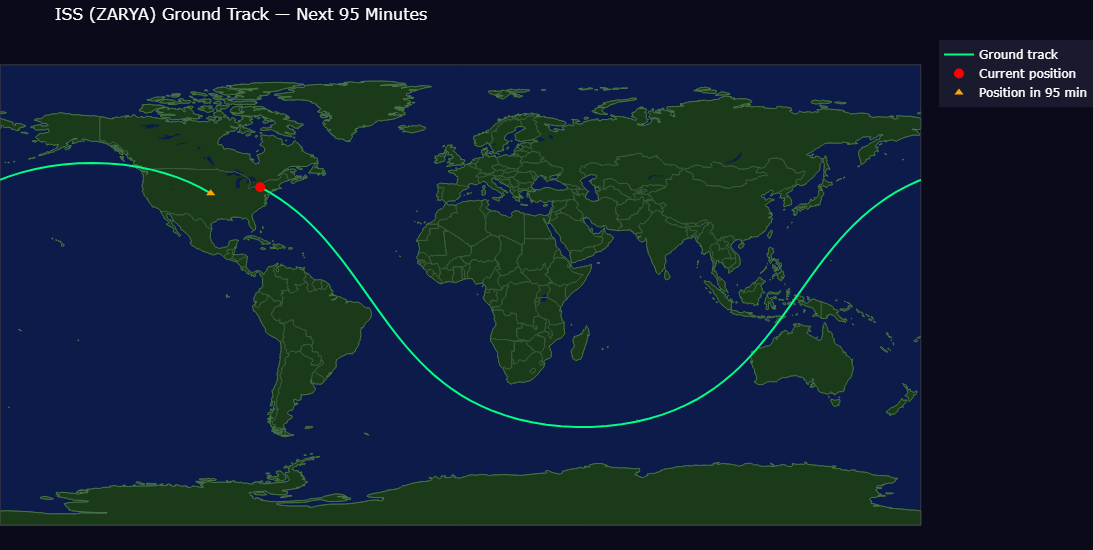

In [80]:
import plotly.graph_objects as go
from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)

def compute_ground_track(satrec, start_dt, duration_minutes=95, step_seconds=60):
  """95 minutes is approximately one ISS orbital period."""
  track = []
  steps = int(duration_minutes * 60 / step_seconds)
  for i in range(steps):
      dt = start_dt + timedelta(seconds=i * step_seconds)
      p = propagate(satrec, dt)
      if p is not None:
          track.append(eci_to_latlon(p, dt))
  return track

track = compute_ground_track(iss_sat, now)
lats = [t[0] for t in track]
lons = [t[1] for t in track]

fig = go.Figure()

# Ground track line
fig.add_trace(go.Scattergeo(
  lat=lats,
  lon=lons,
  mode='lines',
  line=dict(color='#00ff88', width=2),
  name='Ground track',
))

# Current position
fig.add_trace(go.Scattergeo(
  lat=[lats[0]],
  lon=[lons[0]],
  mode='markers',
  marker=dict(color='red', size=10, symbol='circle'),
  name='Current position',
))

# Position in 95 min
fig.add_trace(go.Scattergeo(
  lat=[lats[-1]],
  lon=[lons[-1]],
  mode='markers',
  marker=dict(color='orange', size=8, symbol='triangle-up'),
  name='Position in 95 min',
))

fig.update_layout(
  title=dict(
      text=f'{iss_name} Ground Track — Next 95 Minutes',
      font=dict(color='white', size=16)
  ),
  paper_bgcolor='#0a0a1a',
  geo=dict(
      showland=True,
      landcolor='#1a3a1a',
      showocean=True,
      oceancolor='#0d1b4b',
      showcountries=True,
      countrycolor='#3a5a3a',
      showcoastlines=True,
      coastlinecolor='#4a7a4a',
      coastlinewidth=0.8,
      showlakes=True,
      lakecolor='#0d1b4b',
      bgcolor='#0a0a1a',
      projection_type='equirectangular',
      lonaxis=dict(range=[-180, 180]),
      lataxis=dict(range=[-90, 90]),
  ),
  legend=dict(
      bgcolor='#1a1a2e',
      font=dict(color='white')
  ),
  margin=dict(l=0, r=0, t=40, b=0),
  height=550,
)

iplot(fig)

In [69]:
# Hoboken, NJ
HOBOKEN_LAT = 40.744
HOBOKEN_LON = -74.030

def eci_hoboken(dt):
  """Get ECI coordinates of a point on Earth's surface at a given time."""
  jd, fr = jday(dt.year, dt.month, dt.day, dt.hour, dt.minute, dt.second)
  t = (jd + fr - 2451545.0) / 36525.0
  gmst = (280.46061837 + 360.98564736629 * (jd + fr - 2451545.0)
          + 0.000387933 * t**2 - t**3 / 38710000.0) % 360
  gmst_rad = np.radians(gmst)

  # Convert lat/lon to ECI
  lat_rad = np.radians(HOBOKEN_LAT)
  lon_rad = np.radians(HOBOKEN_LON) + gmst_rad
  R = 6371.0  # Earth radius km

  x = R * np.cos(lat_rad) * np.cos(lon_rad)
  y = R * np.cos(lat_rad) * np.sin(lon_rad)
  z = R * np.sin(lat_rad)
  return np.array([x, y, z])

# Scan next 24 hours in 1-minute steps
times = [now + timedelta(minutes=i) for i in range(1440)]
min_dist = float('inf')
min_time = None
min_alt = None

for t in times:
  sat_pos = propagate(iss_sat, t)
  if sat_pos is None:
      continue
  ground_pos = eci_hoboken(t)
  dist = distance_km(sat_pos, ground_pos)
  if dist < min_dist:
      min_dist = dist
      min_time = t
      # Altitude above Hoboken at closest approach
      min_alt = np.linalg.norm(sat_pos) - 6371.0

# Straight-line distance minus Earth radius = altitude overhead
overhead_dist = min_dist - 6371.0

print(f"Closest ISS pass over Hoboken NJ in the next 24 hours:")
print(f"  Time (UTC)       : {min_time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  Distance (3D)    : {min_dist:.1f} km")
print(f"  ISS altitude     : {min_alt:.1f} km")
print(f"  Horizontal dist  : {(min_dist**2 - min_alt**2)**0.5:.1f} km from directly overhead")

Closest ISS pass over Hoboken NJ in the next 24 hours:
  Time (UTC)       : 2026-03-26 01:23:13
  Distance (3D)    : 477.4 km
  ISS altitude     : 424.1 km
  Horizontal dist  : 219.3 km from directly overhead


---
## 6. Computing Distance Between Two Satellites

Comparing: ISS (ZARYA)  vs  POISK


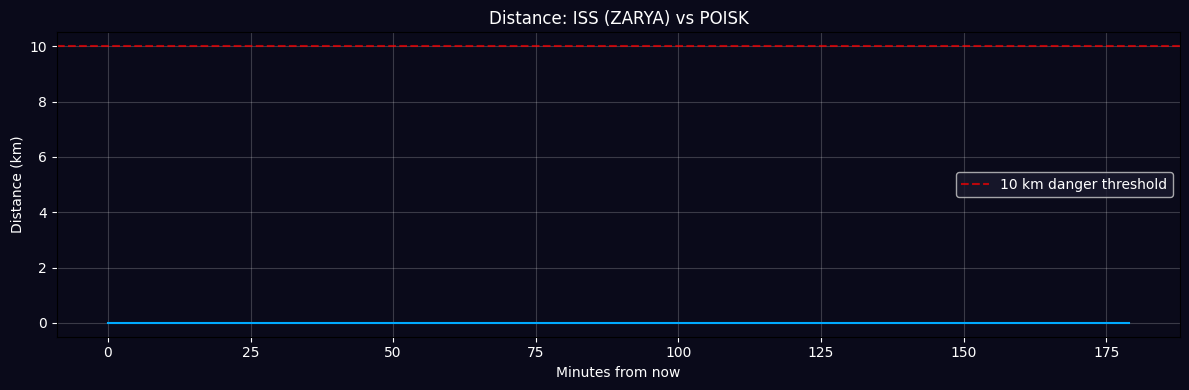

Min distance in next 3h: 0.0 km at t+0 min


In [48]:
def distance_km(pos1, pos2):
    return np.linalg.norm(pos1 - pos2)

sat_a_name, sat_a = build_satrec(*stations[0])
sat_b_name, sat_b = build_satrec(*stations[1]) if len(stations) > 1 else build_satrec(*active_sats[10])

print(f'Comparing: {sat_a_name}  vs  {sat_b_name}')

times = [now + timedelta(minutes=i) for i in range(180)]
distances = []
for t in times:
    pa = propagate(sat_a, t)
    pb = propagate(sat_b, t)
    distances.append(distance_km(pa, pb) if pa is not None and pb is not None else None)

valid = [(i, d) for i, d in enumerate(distances) if d is not None]
xs = [v[0] for v in valid]
ys = [v[1] for v in valid]

fig, ax = plt.subplots(figsize=(12, 4))
ax.set_facecolor('#0a0a1a')
fig.patch.set_facecolor('#0a0a1a')
ax.plot(xs, ys, color='#00aaff', linewidth=1.5)
ax.axhline(y=10, color='red', linestyle='--', alpha=0.7, label='10 km danger threshold')
ax.set_xlabel('Minutes from now', color='white')
ax.set_ylabel('Distance (km)', color='white')
ax.set_title(f'Distance: {sat_a_name} vs {sat_b_name}', color='white')
ax.tick_params(colors='white')
ax.grid(True, alpha=0.2, color='white')
ax.legend(facecolor='#1a1a2e', labelcolor='white')
plt.tight_layout()
plt.show()

print(f'Min distance in next 3h: {min(ys):.1f} km at t+{xs[ys.index(min(ys))]} min')

---
## 7. Basic Conjunction Detector

Scan all satellite pairs and flag anything that comes within a distance threshold.

In [49]:
def find_conjunctions(satellite_list, lookahead_minutes=90, step_minutes=1, threshold_km=500):
    """
    Brute-force O(n^2) conjunction scan.
    Fast enough for small catalogues; notebook 02 replaces this with a k-d tree.
    """
    sats = [(name, Satrec.twoline2rv(l1, l2)) for name, l1, l2 in satellite_list]
    time_steps = [now + timedelta(minutes=i) for i in range(0, lookahead_minutes, step_minutes)]

    # Precompute positions
    positions = {}
    for name, sat in sats:
        for i, t in enumerate(time_steps):
            positions[(name, i)] = propagate(sat, t)

    conjunctions = []
    n = len(sats)
    for i in range(n):
        for j in range(i + 1, n):
            name_a, name_b = sats[i][0], sats[j][0]
            min_dist, min_t = float('inf'), 0
            for t_idx in range(len(time_steps)):
                pa = positions[(name_a, t_idx)]
                pb = positions[(name_b, t_idx)]
                if pa is None or pb is None:
                    continue
                d = distance_km(pa, pb)
                if d < min_dist:
                    min_dist, min_t = d, t_idx
            if min_dist < threshold_km:
                conjunctions.append({
                    'sat_a': name_a,
                    'sat_b': name_b,
                    'min_distance_km': round(min_dist, 2),
                    'time_of_closest_approach': time_steps[min_t],
                    'minutes_from_now': min_t * step_minutes,
                })

    return sorted(conjunctions, key=lambda x: x['min_distance_km'])

subset = stations + active_sats[:30]
print(f'Scanning {len(subset)} satellites...')
results = find_conjunctions(subset)

print(f'Found {len(results)} conjunction events:\n')
df = pd.DataFrame(results)
if not df.empty:
    print(df.to_string(index=False))
else:
    print('No close approaches found — try increasing threshold_km or the subset size.')

Scanning 61 satellites...
Found 55 conjunction events:

         sat_a              sat_b  min_distance_km   time_of_closest_approach  minutes_from_now
   ISS (ZARYA)              POISK             0.00 2026-03-25 18:21:21.215116                 0
   ISS (ZARYA)        ISS (NAUKA)             0.00 2026-03-25 18:21:21.215116                 0
   ISS (ZARYA)     PROGRESS-MS 32             0.00 2026-03-25 18:21:21.215116                 0
   ISS (ZARYA)        SOYUZ-MS 28             0.00 2026-03-25 18:21:21.215116                 0
   ISS (ZARYA)     CREW DRAGON 12             0.00 2026-03-25 18:21:21.215116                 0
   ISS (ZARYA)     PROGRESS-MS 33             0.00 2026-03-25 18:21:21.215116                 0
         POISK        ISS (NAUKA)             0.00 2026-03-25 18:21:21.215116                 0
         POISK     PROGRESS-MS 32             0.00 2026-03-25 18:21:21.215116                 0
         POISK        SOYUZ-MS 28             0.00 2026-03-25 18:21:21.215116   

---
## 8. What We Have & What's Next

### What this notebook established:
- Fetching and parsing real TLE data from Celestrak
- Propagating orbits forward in time with SGP4
- Converting ECI positions to lat/lon for visualization
- Plotting ground tracks
- Computing inter-satellite distances
- A working brute-force conjunction detector

### The main problem to solve next:
The O(n^2) pair scan is too slow for 8,000+ satellites. Notebook 02 introduces **k-d trees** for fast spatial queries.

### Full build order:
```
✅ 01_explore_tle_data.ipynb         <- you are here
⬜ 02_fast_conjunction_search.ipynb  (k-d tree, filtering)
⬜ 03_ml_model_training.ipynb        (risk score model)
⬜ src/ingester.py                   (Kafka producer)
⬜ src/propagator.py                 (Kafka consumer -> Redis)
⬜ src/detector.py                   (conjunction service)
⬜ dashboard/                        (CesiumJS frontend)
```